In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#for linear regression 
from sklearn.linear_model import LinearRegression #machine learning model
from sklearn.preprocessing import StandardScaler #used for feature scaling
from sklearn.model_selection import train_test_split #for training and testing of data
from sklearn.metrics import mean_squared_error,r2_score #to check model accuracy


In [28]:
df=pd.read_csv('Car_Sales.csv')
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner


In [29]:
#label encode for alphabetic record to numeric discrete record
df['fuel'].unique()


<StringArray>
['Petrol', 'Diesel', 'CNG', 'LPG', 'Electric']
Length: 5, dtype: str

In [30]:
fuel_id={
        'Petrol':0,
        'Diesel':1,
        'CNG':2,
        'LPG':3, 
        'Electric':4
    }
df['fuel_id']=df['fuel'].map(fuel_id)


In [31]:
df['seller_type'].unique()

<StringArray>
['Individual', 'Dealer', 'Trustmark Dealer']
Length: 3, dtype: str

In [32]:
seller_type_id={
    'Individual':0,
    'Dealer':1,
    'Trustmark Dealer':2
}
df['seller_type_id']=df['seller_type'].map(seller_type_id)

In [33]:
#transmission order
df['transmission'].unique()

<StringArray>
['Manual', 'Automatic']
Length: 2, dtype: str

In [34]:
transmission_id={
    'Manual':0,
    "Automatic":1
}
df['transmission_id']=df['transmission'].map(transmission_id)

In [35]:
df['owner'].unique()

<StringArray>
[         'First Owner',         'Second Owner', 'Fourth & Above Owner',
          'Third Owner',       'Test Drive Car']
Length: 5, dtype: str

In [36]:
owner_id={
    'First Owner':0,
    'Second Owner':1,
    'Third Owner':2,
    'Fourth & Above Owner':3,
    'Test Drive Car':4

}
df['owner_id']=df['owner'].map(owner_id)

In [37]:
#feature and target
df.columns

Index(['name', 'year', 'selling_price', 'km_driven', 'fuel', 'seller_type',
       'transmission', 'owner', 'fuel_id', 'seller_type_id', 'transmission_id',
       'owner_id'],
      dtype='str')

In [38]:
features=['year','km_driven','fuel_id','seller_type_id','transmission_id','owner_id']
target="selling_price"

In [39]:
X=df[features]# multi dim list
Y=df[target] #single dim list

In [40]:
#train test split
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=42)

In [41]:
#feature scaling
#standard scaler->(X-mean)/sd
scaler=StandardScaler()

In [42]:
#feature testing scaling->does learning+ implementation
X_train_scale=scaler.fit_transform(X_train)
#feature testing scaling-> does implementation only
X_test_scale=scaler.transform(X_test)

In [43]:
X_train_scale

array([[ 0.92342078, -0.98114024,  0.85176567, -0.5549349 , -0.3416984 ,
        -0.62899576],
       [ 1.16122801, -0.34146273,  0.85176567, -0.5549349 , -0.3416984 ,
        -0.62899576],
       [-0.0278081 , -0.87452732, -0.96254746, -0.5549349 , -0.3416984 ,
         0.69939431],
       ...,
       [ 0.68561356, -0.32014015,  0.85176567,  1.46682163, -0.3416984 ,
        -0.62899576],
       [-0.0278081 ,  0.29821478,  0.85176567, -0.5549349 , -0.3416984 ,
        -0.62899576],
       [-0.0278081 ,  0.29821478, -0.96254746, -0.5549349 , -0.3416984 ,
        -0.62899576]], shape=(3472, 6))

In [44]:
#use of linear regression model
from sklearn.linear_model import LinearRegression
model=LinearRegression()
#training model with feature scaled and target data

model.fit(X_train_scale,Y_train)
#model.fit(X_train_scale)
#testing data to make model learn its patterns so it can predict future upcoming values
Y_pred= model.predict(X_test_scale)

In [45]:
X_train_scale.shape

(3472, 6)

In [46]:
Y_train.shape

(3472,)

In [47]:
#machine learining
'''
scikit-learn---> day 2
'''

'\nscikit-learn---> day 2\n'

In [48]:
#mean squared error(ecludeian disance R2)->actual from where the prediction starts
#model accuracy
rmse=np.sqrt(mean_squared_error(Y_test,Y_pred))
#R2 score->Accuracy number of how well model performs?
r2=r2_score(Y_test,Y_pred)
print(f'root mean squared error:{rmse}')
print(f'R2 score (Accuracy):{r2}')


root mean squared error:432407.7429128674
R2 score (Accuracy):0.3873045160130879


In [49]:
#for straight line
x_min,x_max=[Y_test.min(),Y_test.max()] #straight line for horizontal
y_min,y_max=[Y_test.min(),Y_test.max()]# for vertical

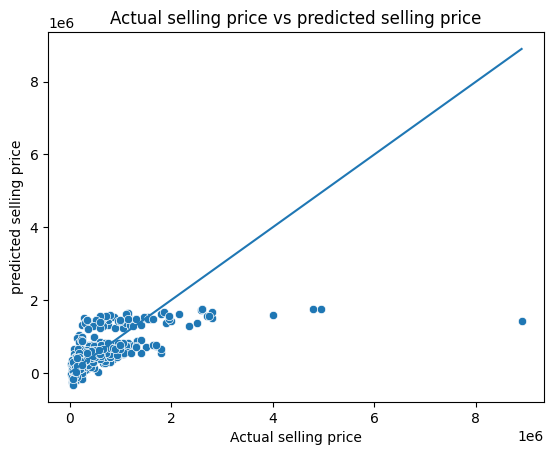

In [50]:
#model accuracy
#visualization

#straight line
#the use of flatten is same as a ravel , 
# convert any dimension array into 1D array
sns.scatterplot(x=Y_test.values.flatten(),y=Y_pred.flatten())
plt.plot([x_min,x_max],[y_min,y_max])
plt.xlabel('Actual selling price')
plt.ylabel('predicted selling price')
plt.title('Actual selling price vs predicted selling price')
plt.show()

#new data prediction

In [51]:
#random forest regressor, ML algo
from sklearn.ensemble import RandomForestRegressor
rf_model=RandomForestRegressor(n_estimators=100,random_state=42)
rf_model.fit(X_train,Y_train)
rf_pred=rf_model.predict(X_test)

In [54]:
rf_rmse=np.sqrt(mean_squared_error(Y_test,rf_pred))
rf_r2=r2_score(Y_test,rf_pred)
print(f'RAndom forest RMSE: {rf_rmse}')
print(f'Random forest R2 score ( accuracy):{rf_r2}')

RAndom forest RMSE: 391259.9346394743
Random forest R2 score ( accuracy):0.4983642135733023


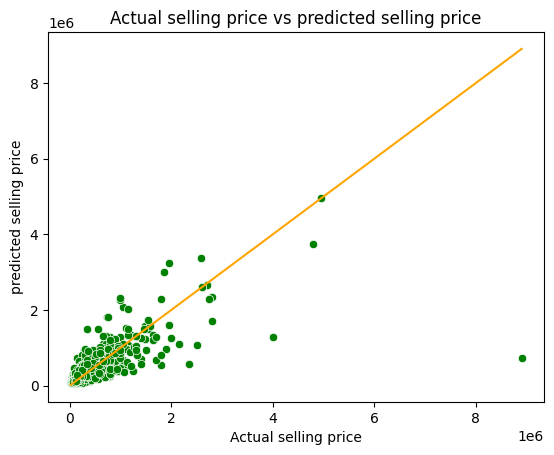

In [55]:
sns.scatterplot(x=Y_test.values.flatten(),y=rf_pred.flatten(),color='green')
plt.plot([x_min,x_max],[y_min,y_max],color='orange')
plt.xlabel('Actual selling price')
plt.ylabel('predicted selling price')
plt.title('Actual selling price vs predicted selling price')
plt.show()